In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from analysis_utils import simulate_and_plot

### Simulating in poor nutrients

In [2]:
k_n0 = 1.5 # nutrient quality

# gene expression parameters
tau_r = 6.25
tau_u = 0.0625
sigma_u = 0.3

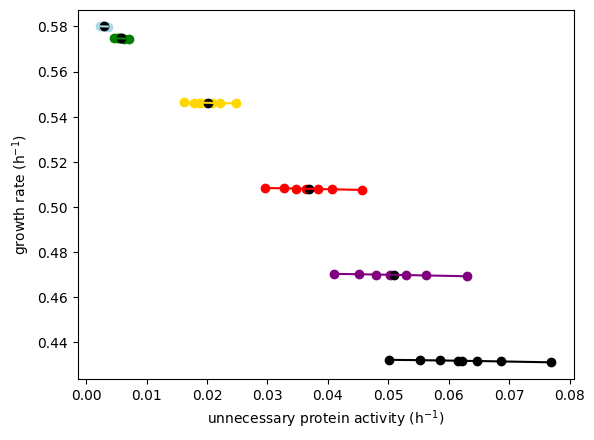

In [3]:
ribo_div_noise = 0.00

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

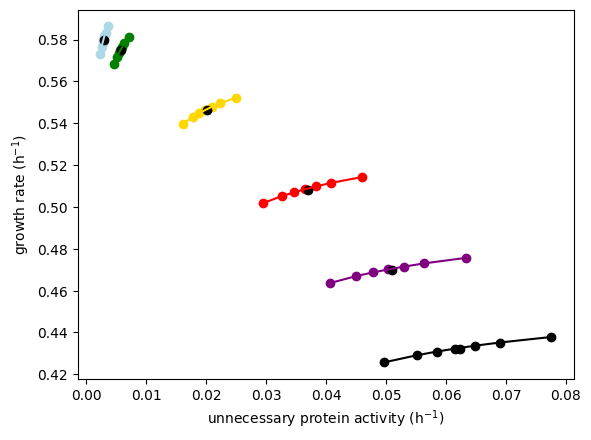

In [4]:
ribo_div_noise = 0.02

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

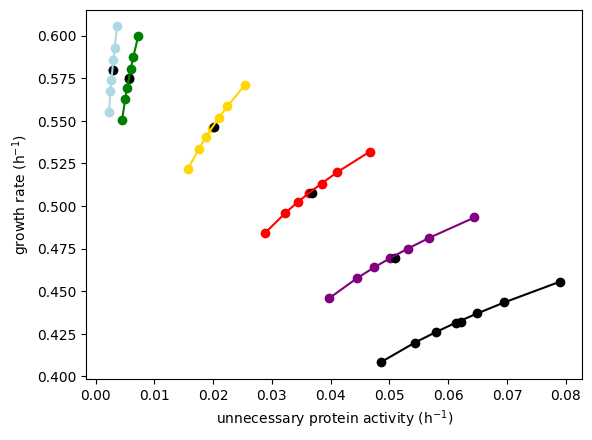

In [5]:
ribo_div_noise = 0.04

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

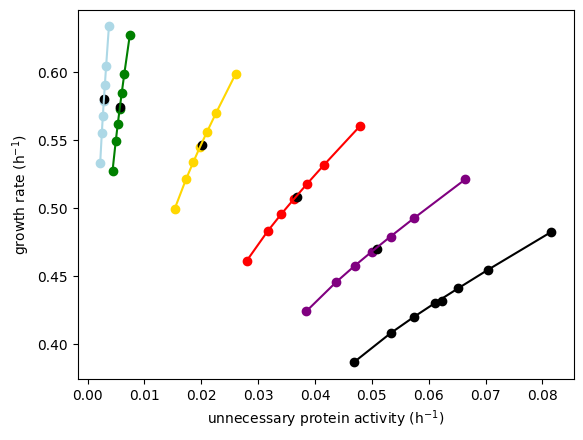

In [6]:
ribo_div_noise = 0.06

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

### Simulating in rich nutrients

In [2]:
k_n0 = 3.43 # nutrient quality

# gene expression parameters
tau_r = 6.25
tau_u = 0.0625
sigma_u = 0.3

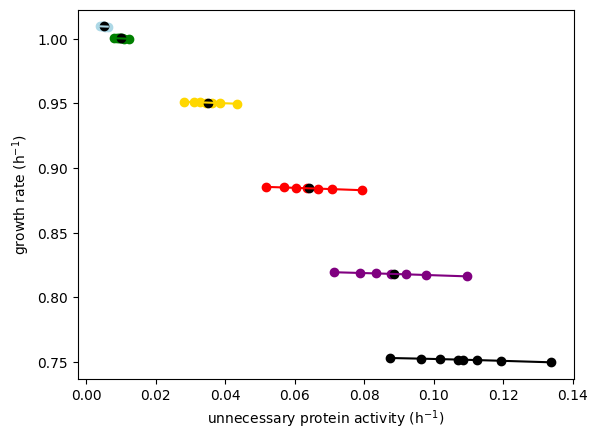

In [3]:
ribo_div_noise = 0.00

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

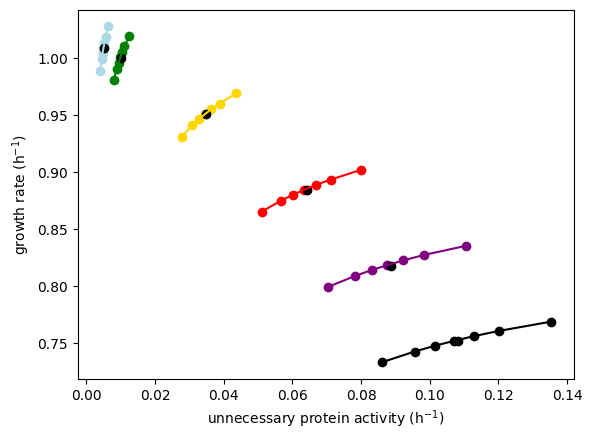

In [4]:
ribo_div_noise = 0.02

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

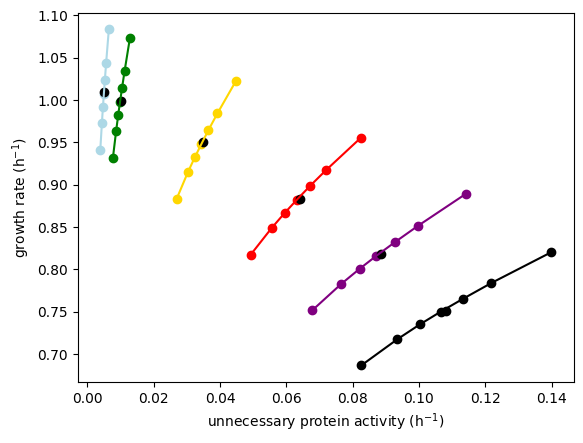

In [5]:
ribo_div_noise = 0.04

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

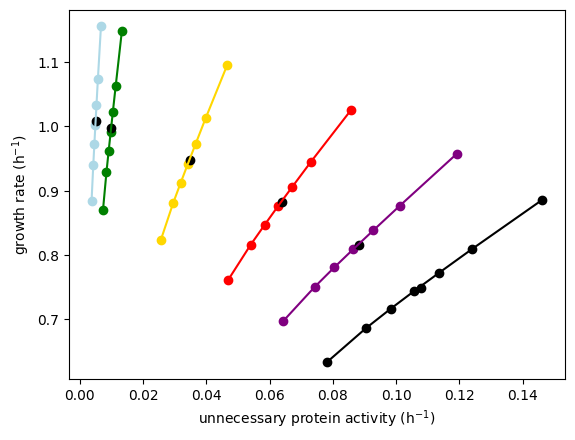

In [6]:
ribo_div_noise = 0.06

simulate_and_plot(tau_r, tau_u, sigma_u, ribo_div_noise, k_n0)

#### Further analysis relating activity to mass fraction

In [ ]:
# import saved simulation results
df_act = pd.read_csv('activity_rich_riboDivNoise_0p06.csv')
df_gr = pd.read_csv('growthRate_rich_riboDivNoise_0p06.csv')
df_act = df_act.drop(columns=df_act.columns[0]) # dropping index
df_gr = df_gr.drop(columns=df_gr.columns[0])

df_act_poor = pd.read_csv('activity_poor_riboDivNoise_0p06.csv')
df_gr_poor = pd.read_csv('growthRate_poor_riboDivNoise_0p06.csv')
df_act_poor = df_act_poor.drop(columns=df_act_poor.columns[0]) # dropping index
df_gr_poor = df_gr_poor.drop(columns=df_gr_poor.columns[0])

In [30]:
gr_rich = [df_gr[df_gr.columns[i]].mean() for i in range(len(df_gr.columns))]
act_rich = [df_act[df_act.columns[i]].mean() for i in range(len(df_act.columns))]

gr_poor = [df_gr_poor[df_gr_poor.columns[i]].mean() for i in range(len(df_gr_poor.columns))]
act_poor = [df_act_poor[df_act_poor.columns[i]].mean() for i in range(len(df_act_poor.columns))]

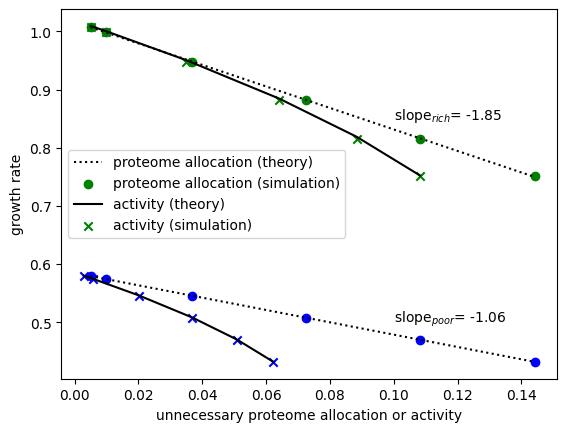

In [31]:
pa_func = lambda A,phi_C,K_0: (K_0 + np.sqrt(K_0**2 - 4*K_0*A/phi_C)) / 2
lin_mod = lambda x,p: p[0]*x + p[1]

# plt.plot(act_rich,gr_rich)
fU_rich = np.array(act_rich)/np.array(gr_rich)
fU_poor = np.array(act_poor)/np.array(gr_poor)
p_rich = np.polyfit(fU_rich,np.array(gr_rich),deg=1)
p_poor = np.polyfit(fU_poor,np.array(gr_poor),deg=1)

plt.plot(fU_rich,lin_mod(fU_rich,p_rich), linestyle=':', color='k', label='proteome allocation (theory)')
plt.plot(fU_poor,lin_mod(fU_poor,p_poor), linestyle=':', color='k')
plt.scatter(fU_rich,gr_rich, color='green', label='proteome allocation (simulation)')
plt.scatter(fU_poor,gr_poor, color='blue')

gr_rich_0 = 1.0188209227847578
gr_poor_0 = 0.5852954576986202
plt.plot(np.array(act_rich),pa_func(np.array(act_rich),0.55,gr_rich_0), color='k', label='activity (theory)')
plt.plot(np.array(act_poor),pa_func(np.array(act_poor),0.55,gr_poor_0), color='k')
plt.scatter(act_rich,gr_rich, color='green', marker='x', label='activity (simulation)')
plt.scatter(act_poor,gr_poor, color='blue', marker='x')

plt.annotate('slope$_{rich}$= '+str(np.round(p_rich[0],2)),xy=(0.1,0.85))
plt.annotate('slope$_{poor}$= '+str(np.round(p_poor[0],2)),xy=(0.1,0.5))
plt.ylabel('growth rate')
plt.xlabel('unnecessary proteome allocation or activity')
plt.legend()
plt.show()